# 05 - Análise e Respostas de Negócio
Execute após a validação de qualidade. Salve screenshots das tabelas e gráficos exibidos.

In [0]:
%run ./00_setup

# 00 - Configuração
Cria objetos do Unity Catalog e caminhos do MVP. Ajuste os widgets antes da primeira execução.

Envie COTAHIST_A2025.TXT para: /Volumes/workspace/mvp_b3/landing/cotahist/
Envie setores_b3.csv para: /Volumes/workspace/mvp_b3/landing/referencia/


In [0]:
from pyspark.sql import functions as F


## Pergunta 1 - Desempenho dos setores mais negociados

In [0]:
setores = spark.table(f"{catalog}.{schema}.agg_desempenho_setor").orderBy(F.col("volume_medio_diario").desc())
display(setores)

setor,quantidade_ativos,volume_medio_diario,retorno_mediano_12m,volatilidade_mediana,pct_acima_mm200
FINANCEIRO,29,3.5764418768919997E9,0.35174746335963936,0.2708526361152566,0.8275862068965517
"PETRÓLEO, GÁS E BIOCOMBUSTÍVEIS",11,2.631030114184E9,-0.1961994076999013,0.35015106841907123,0.36363636363636365
MATERIAIS BÁSICOS,22,2.247931469992E9,0.061757719714964354,0.3293016825739362,0.6363636363636364
CONSUMO CÍCLICO,47,2.1479854376655164E9,0.46516007532956705,0.4552525098636278,0.574468085106383
UTILIDADE PÚBLICA,23,2.0025753381200678E9,0.5077427376511812,0.24729716590193707,0.8260869565217391
BENS INDUSTRIAIS,32,1.4740106703844123E9,-0.015437392795883298,0.36972031048366294,0.46875
CONSUMO NÃO CÍCLICO,15,1.181148679450725E9,-0.029982363315696592,0.3708974559353661,0.3333333333333333
SAÚDE,16,7.852723645839999E8,0.3213684800897365,0.4458784900291522,0.6875
COMUNICAÇÕES,5,2.91632508922251E8,0.43768115942028984,0.5272630108112366,0.4
TECNOLOGIA DA INFORMAÇÃO,9,2.15748015592E8,0.3107692307692307,0.4749056385662234,0.6666666666666666


Configure no Databricks um gráfico de barras: setor no eixo X, retorno_mediano_12m no eixo Y e volume_medio_diario como informação adicional.

## Pergunta 2 - Cenário quantitativo observado

In [0]:
ativos = spark.table(f"{catalog}.{schema}.ranking_ativos_analise")
mercado = ativos.agg(
    F.percentile_approx("retorno_12m", 0.5).alias("retorno_mediano"),
    F.avg("tendencia_200").alias("pct_acima_mm200"),
    F.percentile_approx("volatilidade_anual", 0.5).alias("volatilidade_mediana"),
    F.count("*").alias("ativos_avaliados")
).withColumn(
    "cenario",
    F.when((F.col("retorno_mediano") > 0.05) & (F.col("pct_acima_mm200") >= 0.60), "FAVORAVEL")
     .when((F.col("retorno_mediano") < -0.05) & (F.col("pct_acima_mm200") < 0.40), "DESFAVORAVEL")
     .otherwise("NEUTRO/INDEFINIDO")
).withColumn(
    "interpretacao",
    F.concat(F.lit("Classificação condicional baseada em retorno mediano e participação acima da MM200; não representa previsão ou garantia."))
)
display(mercado)

retorno_mediano,pct_acima_mm200,volatilidade_mediana,ativos_avaliados,cenario,interpretacao
0.27247451343836904,0.6076555023923444,0.3656608242688187,209,FAVORAVEL,Classificação condicional baseada em retorno mediano e participação acima da MM200; não representa previsão ou garantia.


## Pergunta 3 - Ativos para aprofundar a análise

In [0]:
ranking = (ativos.select("posicao", "ticker", "setor", "score_final", "retorno_12m", "volatilidade_anual",
                          "volume_medio_diario", "tendencia_200")
           .orderBy("posicao").limit(15))
display(ranking)

posicao,ticker,setor,score_final,retorno_12m,volatilidade_anual,volume_medio_diario,tendencia_200
1,ELET3,UTILIDADE PÚBLICA,89.74,0.7258823529411764,0.23184899747017698,3.36866860898148E8,1
2,ENEV3,UTILIDADE PÚBLICA,87.04,1.1130890052356017,0.2666542073540892,1.46790775156E8,1
3,CPFE3,UTILIDADE PÚBLICA,85.46,0.6960534691279439,0.2052090933154822,6.9215153728E7,1
4,CPLE6,UTILIDADE PÚBLICA,84.09,0.5687568756875687,0.20541202836552,1.51565940055556E8,1
5,ELET6,UTILIDADE PÚBLICA,83.94,0.6373248744382765,0.22619618935751237,6.8531256E7,1
6,CSMG3,UTILIDADE PÚBLICA,83.8,1.139308329274233,0.28955221656341545,6.7504575916E7,1
7,VALE3,MATERIAIS BÁSICOS,80.34,0.3264516129032258,0.23415799849441596,1.330630537984E9,1
8,ORVR3,UTILIDADE PÚBLICA,79.98,0.8521854304635763,0.24729716590193707,2.5795884724E7,1
9,ALOS3,FINANCEIRO,79.88,0.565673289183223,0.23725162212859416,9.5125463216E7,1
10,SRNA3,UTILIDADE PÚBLICA,79.21,1.3901515151515147,0.28069908880750755,5.3152146086364E7,1


**Leitura responsável:** o ranking é uma triagem acadêmica baseada apenas no histórico de mercado. Antes de investir, investigue fundamentos, valuation, governança, endividamento, eventos corporativos e adequação ao seu perfil. Não há garantia de retorno futuro.


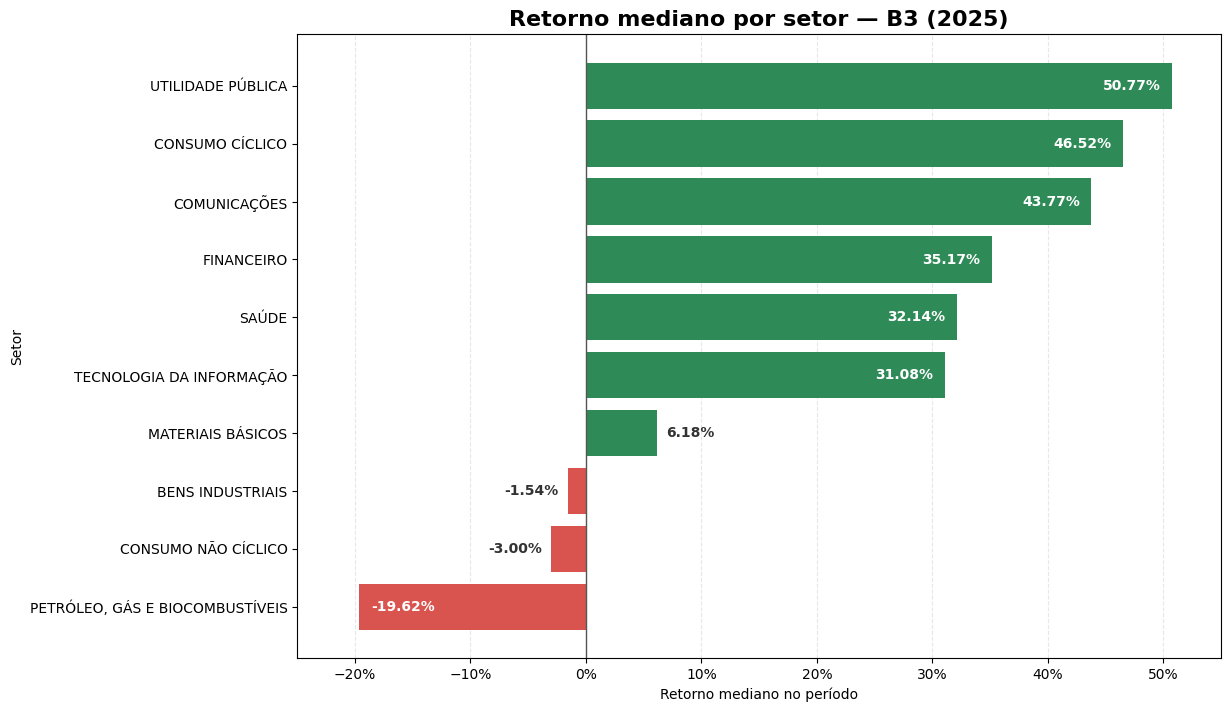

In [0]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

grafico_setores = (
    setores
    .select("setor", "retorno_mediano_12m")
    .toPandas()
    .sort_values("retorno_mediano_12m", ascending=True)
)

grafico_setores["retorno_percentual"] = (
    grafico_setores["retorno_mediano_12m"] * 100
)

cores = [
    "#2E8B57" if valor >= 0 else "#D9534F"
    for valor in grafico_setores["retorno_percentual"]
]

fig, ax = plt.subplots(figsize=(14, 8))

barras = ax.barh(
    grafico_setores["setor"],
    grafico_setores["retorno_percentual"],
    color=cores
)

ax.axvline(0, color="#555555", linewidth=1)

# Posicionamento inteligente dos percentuais
for barra, valor in zip(
    barras,
    grafico_setores["retorno_percentual"]
):
    posicao_y = barra.get_y() + barra.get_height() / 2

    if valor >= 8:
        # Valores positivos maiores ficam dentro da barra
        posicao_x = valor - 1
        alinhamento = "right"
        cor_texto = "white"

    elif valor <= -8:
        # Valores negativos maiores ficam dentro da barra
        posicao_x = valor + 1
        alinhamento = "left"
        cor_texto = "white"

    elif valor >= 0:
        # Valores positivos pequenos ficam fora da barra
        posicao_x = valor + 0.8
        alinhamento = "left"
        cor_texto = "#333333"

    else:
        # Valores negativos pequenos ficam próximos ao zero
        posicao_x = valor - 0.8
        alinhamento = "right"
        cor_texto = "#333333"

    ax.text(
        posicao_x,
        posicao_y,
        f"{valor:.2f}%",
        va="center",
        ha=alinhamento,
        fontsize=10,
        fontweight="bold",
        color=cor_texto
    )

ax.set_title(
    "Retorno mediano por setor — B3 (2025)",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Retorno mediano no período")
ax.set_ylabel("Setor")

# Espaço adicional nos dois extremos
ax.set_xlim(-25, 55)

ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Mais espaço para os nomes longos dos setores
plt.subplots_adjust(
    left=0.30,
    right=0.96,
    top=0.90,
    bottom=0.12
)

plt.show()